In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Life Expectancy Data.csv")
data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [2]:
data.isnull().sum()


Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [3]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data.groupby('Country')[numeric_cols].transform(
    lambda x: x.fillna(x.median())
)
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
data.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

In [4]:
data.columns = data.columns.str.strip()
print(data.columns.tolist())

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [5]:
print("Duplicate rows:" , data.duplicated().sum())

Duplicate rows: 0


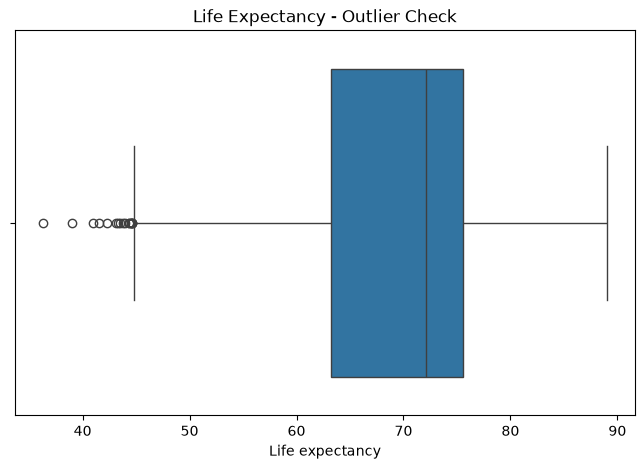

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data['Life expectancy'])
plt.title('Life Expectancy - Outlier Check')
plt.show()

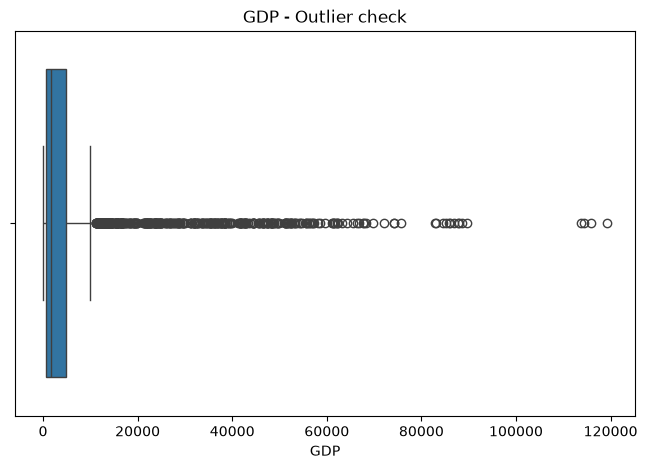

In [7]:
plt.figure(figsize = (8,5))
sns.boxplot(x=data['GDP'])
plt.title('GDP - Outlier check')
plt.show()

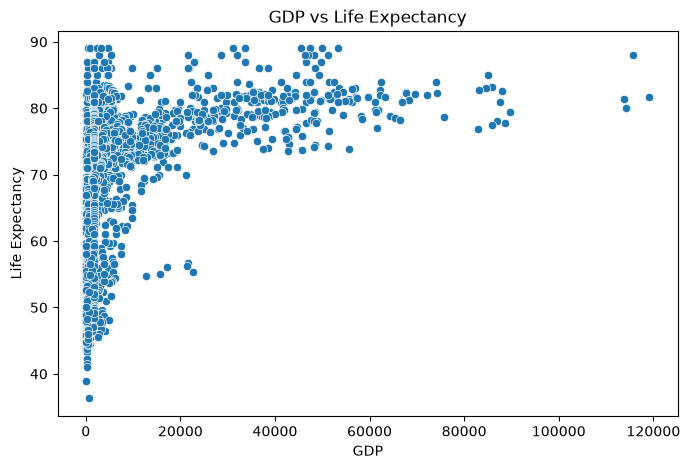

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data['GDP'], y=data['Life expectancy'])
plt.title('GDP vs Life Expectancy')
plt.xlabel('GDP')
plt.ylabel('Life Expectancy')
plt.show()

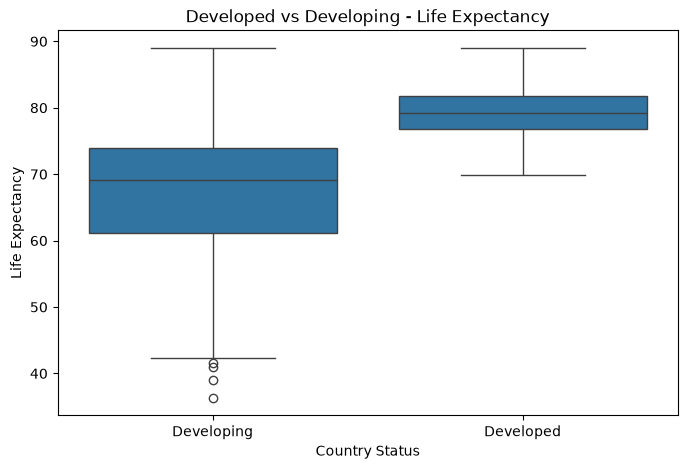

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data['Status'], y=data['Life expectancy'])
plt.title('Developed vs Developing - Life Expectancy')
plt.xlabel('Country Status')
plt.ylabel('Life Expectancy')
plt.show()

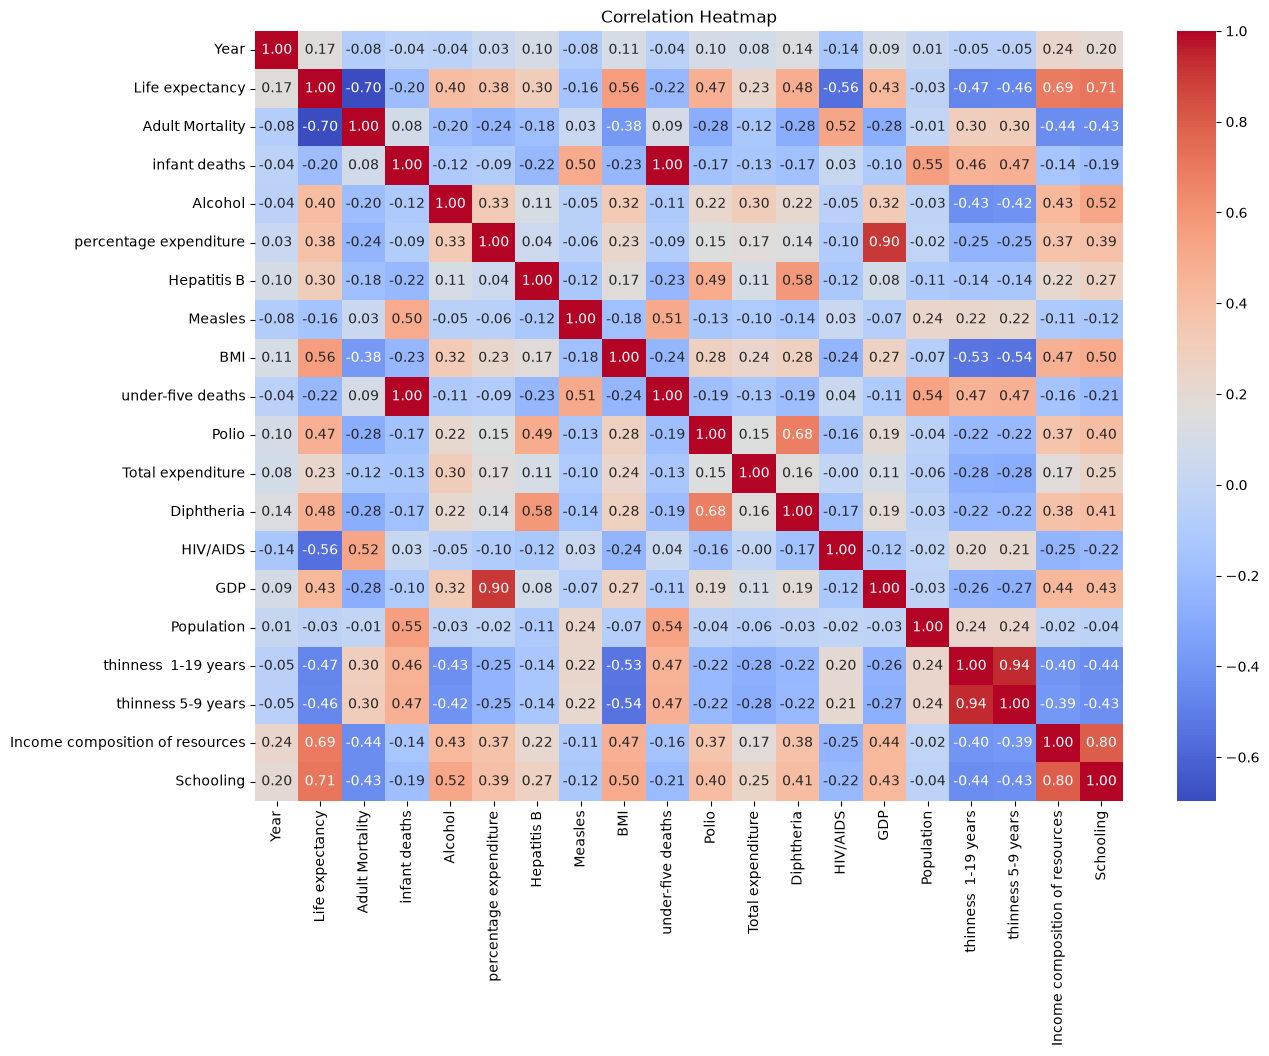

In [10]:
plt.figure(figsize=(14,10))
numeric_data = data.select_dtypes(include=[np.number])
correlation = numeric_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

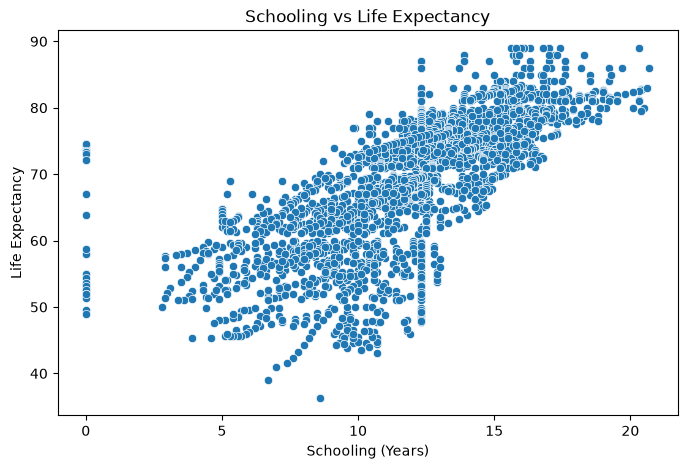

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data['Schooling'], y=data['Life expectancy'])
plt.title('Schooling vs Life Expectancy')
plt.xlabel('Schooling (Years)')
plt.ylabel('Life Expectancy')
plt.show()

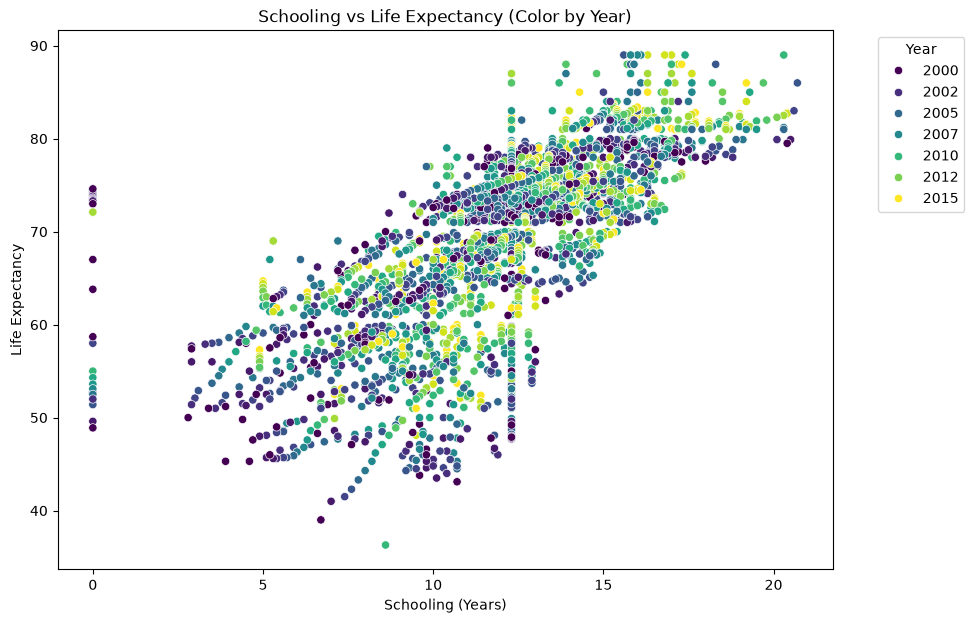

In [12]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=data['Schooling'], y=data['Life expectancy'], hue=data['Year'], palette='viridis')
plt.title('Schooling vs Life Expectancy (Color by Year)')
plt.xlabel('Schooling (Years)')
plt.ylabel('Life Expectancy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Year')
plt.show()

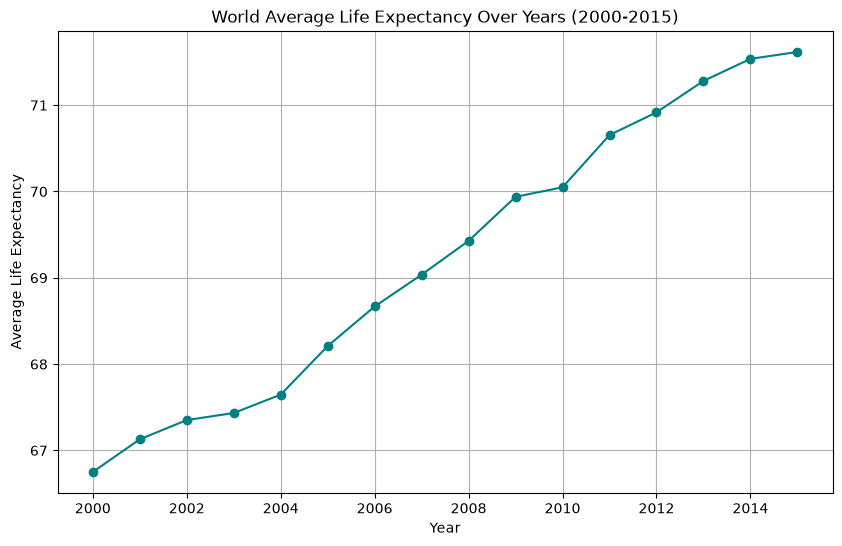

In [13]:
yearly_avg = data.groupby('Year')['Life expectancy'].mean()

plt.figure(figsize=(10,6))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', color='teal')
plt.title('World Average Life Expectancy Over Years (2000-2015)')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy')
plt.grid(True)
plt.show()

## Key Findings

1. **Schooling has the strongest positive correlation (0.71)** with life expectancy — stronger than GDP (0.43), suggesting education access may be as important as economic wealth for health outcomes.

2. **Adult Mortality (-0.70) and HIV/AIDS (-0.56)** show the strongest negative correlations — countries with higher adult death rates and HIV/AIDS prevalence have significantly lower life expectancy.

3. **Developed countries have ~10 years higher median life expectancy** (79 years) than developing countries (69 years), with developing countries showing much wider variation.

4. **GDP correlates positively with life expectancy (0.43) but non-linearly** — the relationship is strong at lower GDP levels and plateaus at higher GDP, suggesting wealth alone doesn't guarantee better health outcomes beyond a certain point.

5. **World average life expectancy rose steadily from 66.7 (2000) to 71.6 (2015)** — a 5-year improvement over 15 years, reflecting global advances in healthcare and disease control.

6. **GDP distribution is highly unequal across countries** — most nations cluster at lower GDP levels, with a small number of developed countries showing significantly higher GDP (outliers).